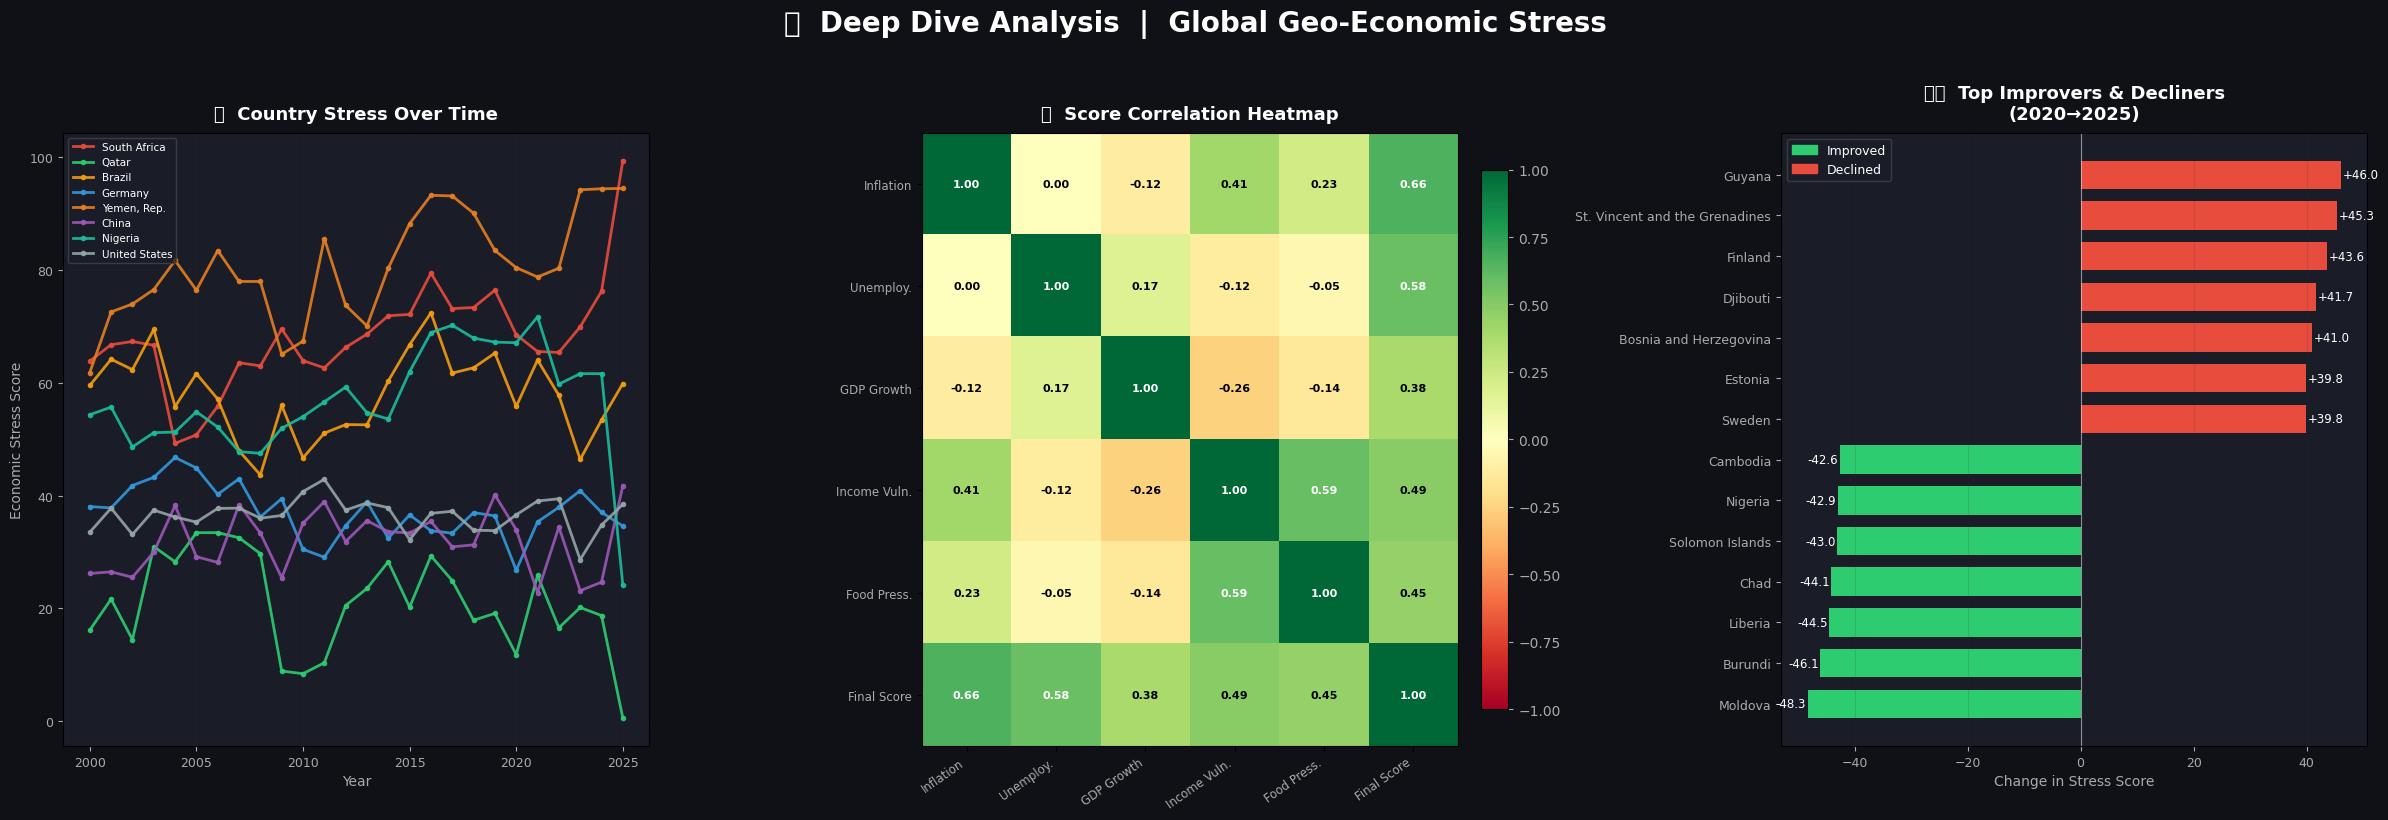

✅ Deep dive charts saved!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── LOAD (skip if already loaded) ────────────────────────────
path = '/kaggle/input/datasets/sateasinpedas/global-geo-economic-stress-indicators/'
df_stress = pd.read_csv(path + 'economic_stress_score.csv')
df_meta   = pd.read_csv(path + 'country_metadata.csv')

cat_colors = {'Low':'#2ecc71','Moderate':'#f1c40f','High':'#e67e22','Severe':'#e74c3c'}
recent = df_stress[df_stress['year'] >= 2000].dropna(subset=['final_economic_stress_score'])
latest_year = recent['year'].max()
latest = recent[recent['year'] == latest_year].copy()
latest['color'] = latest['stress_category'].map(cat_colors).fillna('#95a5a6')

bg   = '#1a1d27'
grid = '#2a2d3a'
title_kw = dict(fontsize=13, fontweight='bold', color='white', pad=10)
label_kw = dict(fontsize=10, color='#aaaaaa')
tick_kw  = dict(colors='#aaaaaa', labelsize=9)

fig2, axes = plt.subplots(1, 3, figsize=(24, 8), facecolor='#0f1117')
fig2.suptitle('📊  Deep Dive Analysis  |  Global Geo-Economic Stress',
              fontsize=20, fontweight='bold', color='white', y=1.02)

# ── CHART A: Country Comparison Over Time ────────────────────
ax_a = axes[0]
ax_a.set_facecolor(bg)

# Pick 8 interesting countries across stress levels
countries = ['South Africa', 'Qatar', 'Brazil', 'Germany',
             'Yemen, Rep.', 'China', 'Nigeria', 'United States']
line_colors = ['#e74c3c','#2ecc71','#f39c12','#3498db',
               '#e67e22','#9b59b6','#1abc9c','#95a5a6']

for country, color in zip(countries, line_colors):
    data = recent[recent['country_name'] == country].sort_values('year')
    if len(data) > 0:
        ax_a.plot(data['year'], data['final_economic_stress_score'],
                  label=country, color=color, linewidth=2, marker='o',
                  markersize=3, alpha=0.9)

ax_a.set_title('📈  Country Stress Over Time', **title_kw)
ax_a.set_xlabel('Year', **label_kw)
ax_a.set_ylabel('Economic Stress Score', **label_kw)
ax_a.tick_params(**tick_kw)
ax_a.grid(alpha=0.15, color=grid)
ax_a.legend(fontsize=7.5, facecolor=bg, edgecolor='#444',
            labelcolor='white', loc='upper left')

# ── CHART B: Correlation Heatmap ──────────────────────────────
ax_b = axes[1]
ax_b.set_facecolor(bg)

score_cols = ['inflation_score','unemployment_score','gdp_growth_score',
              'income_vulnerability_score','food_pressure_score',
              'final_economic_stress_score']
col_labels  = ['Inflation','Unemploy.','GDP Growth',
               'Income Vuln.','Food Press.','Final Score']

corr = recent[score_cols].corr()
im   = ax_b.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

ax_b.set_xticks(range(len(col_labels)))
ax_b.set_yticks(range(len(col_labels)))
ax_b.set_xticklabels(col_labels, rotation=35, ha='right',
                     fontsize=8.5, color='#aaaaaa')
ax_b.set_yticklabels(col_labels, fontsize=8.5, color='#aaaaaa')

for i in range(len(col_labels)):
    for j in range(len(col_labels)):
        val = corr.values[i, j]
        ax_b.text(j, i, f'{val:.2f}', ha='center', va='center',
                  fontsize=8, color='black' if abs(val) < 0.5 else 'white',
                  fontweight='bold')

plt.colorbar(im, ax=ax_b, fraction=0.046, pad=0.04).ax.tick_params(colors='#aaaaaa')
ax_b.set_title('🔗  Score Correlation Heatmap', **title_kw)

# ── CHART C: Top Improvers & Decliners ───────────────────────
ax_c = axes[2]
ax_c.set_facecolor(bg)

# Compare 5 years ago vs latest
year_old  = latest_year - 5
old_data  = recent[recent['year'] == year_old][['country_name','final_economic_stress_score']]
old_data  = old_data.rename(columns={'final_economic_stress_score': 'score_old'})
new_data  = latest[['country_name','final_economic_stress_score']].rename(
                columns={'final_economic_stress_score': 'score_new'})

change_df = new_data.merge(old_data, on='country_name').dropna()
change_df['change'] = change_df['score_new'] - change_df['score_old']

top_improvers = change_df.nsmallest(7, 'change')   # most improved (lower = better)
top_decliners = change_df.nlargest(7, 'change')    # most declined

combined = pd.concat([
    top_improvers.assign(type='Improved'),
    top_decliners.assign(type='Declined')
]).sort_values('change')

bar_colors = ['#2ecc71' if t == 'Improved' else '#e74c3c'
              for t in combined['type']]
bars_ch = ax_c.barh(combined['country_name'], combined['change'],
                    color=bar_colors, edgecolor='none', height=0.7)

for bar, val in zip(bars_ch, combined['change']):
    xpos = bar.get_width() + (0.3 if val >= 0 else -0.3)
    ha   = 'left' if val >= 0 else 'right'
    ax_c.text(xpos, bar.get_y() + bar.get_height()/2,
              f'{val:+.1f}', va='center', fontsize=8.5,
              color='white', ha=ha)

ax_c.axvline(0, color='white', linewidth=0.8, alpha=0.5)
ax_c.set_title(f'📉📈  Top Improvers & Decliners\n({year_old}→{latest_year})', **title_kw)
ax_c.set_xlabel('Change in Stress Score', **label_kw)
ax_c.tick_params(**tick_kw)
ax_c.grid(axis='x', alpha=0.15, color=grid)

improved_patch = mpatches.Patch(color='#2ecc71', label='Improved')
declined_patch = mpatches.Patch(color='#e74c3c', label='Declined')
ax_c.legend(handles=[improved_patch, declined_patch], fontsize=9,
            facecolor=bg, edgecolor='#444', labelcolor='white')

plt.tight_layout()
plt.savefig('geo_economic_stress_deepdive.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Deep dive charts saved!")

# 🌍 Global Geo-Economic Stress Analysis (2025)
### A country-level analysis of economic stress across 182 nations using World Bank & FAOSTAT data

---

**Author:** Rashid Kiplagat  
**Data Source:** [Global Geo-Economic Stress Indicators](https://www.kaggle.com/datasets/sateasinpedas/global-geo-economic-stress-indicators) — World Bank & FAOSTAT  
**Tools:** Python · Pandas · NumPy · Matplotlib  

---

## 📌 Project Overview

Economic stress is rarely caused by one factor alone. A country may face high inflation, 
weak GDP growth, rising unemployment, low income levels, or food production pressure — 
or all of these at once.

This notebook analyses **182 countries** across **25+ years of data** to answer:

> **Which countries show the highest economic stress, and what drives it?**

### Key Indicators Analysed:
| Indicator | Description |
|---|---|
| 🔴 Inflation Score | Price stability pressure |
| 🟠 Unemployment Score | Labour market health |
| 🔵 GDP Growth Score | Economic momentum |
| 🟣 Income Vulnerability | Per capita income risk |
| 🟢 Food Pressure | Food production & supply adequacy |

---
## 📊 Dashboard 1: Global Overview (2025)

The map below shows economic stress across all 182 countries, with bubble size 
proportional to stress score. Red/orange clusters reveal the most at-risk regions.

**Key observations:**
- 🔴 **Sub-Saharan Africa** dominates the severe stress zone
- 🟡 **Middle East & Latin America** show moderate-to-high stress
- 🟢 **East Asia & Pacific** is the most stable region globally
- 💡 **Upper middle income** countries (58.5 avg) are paradoxically MORE stressed than low income (43.4)

---
## 🔬 Dashboard 2: Deep Dive Analysis

### 📈 Country Stress Trajectories (2000–2025)
Tracking 8 countries reveals diverging paths:
- **South Africa** has seen a dramatic rise, reaching near-severe levels by 2025
- **Qatar** remains consistently low — a model of economic stability
- **Yemen** shows extreme volatility driven by conflict and food insecurity

### 🔗 What Drives the Final Stress Score?
The correlation heatmap reveals:
- **Income vulnerability** (0.59) and **food pressure** (0.45) are the strongest 
  contributors to the final stress score
- **GDP growth** has a weak negative correlation (-0.14) — growth alone doesn't 
  reduce stress if inequality persists

### 📉 Biggest Changes (2020→2025)
- **Moldova** improved the most (-48.8) — likely reflecting EU accession progress
- **Guyana** declined the most (+46.0) — rapid oil boom creating inequality pressures
- **Burundi & Liberia** showed strong improvements in food security metrics

---
## 💡 Key Findings & Conclusions

| Finding | Insight |
|---|---|
| 🌍 Global avg stress: **50.3/100** | Half the world under moderate-to-severe stress |
| 🔴 Most stressed: **Eswatini (100)** | Unemployment + income vulnerability dominant |
| 🟢 Least stressed: **Qatar (0.6)** | Oil wealth buffers all stress dimensions |
| 📊 Most stressed region: **MENA (58.8)** | Conflict, inflation & food pressure combined |
| 💰 Income paradox | Upper-middle income countries MORE stressed than low income |
| 📈 Rising trend | Global stress has increased since 2015 |

### 🎯 Policy Implications
1. **Food security interventions** have the highest impact on reducing overall stress
2. **Income redistribution** matters more than raw GDP growth
3. **Regional cooperation** in MENA and Sub-Saharan Africa is urgently needed

---
*Data: World Bank & FAOSTAT | Analysis: Rashid Kiplagat | June 2025*

readme = """# 🌍 Global Geo-Economic Stress Analysis (2025)

![Dashboard](geo_economic_stress_dashboard.png)

## Overview
A comprehensive analysis of economic stress across **182 countries** using 
World Bank & FAOSTAT data, covering 25+ years of indicators including 
inflation, unemployment, GDP growth, income vulnerability, and food pressure.

## Key Findings
- 🌍 **Global average stress score: 50.3/100** — half the world under moderate-to-severe stress
- 🔴 **Most stressed:** Eswatini (100.0), South Africa (99.5), Djibouti (98.9)
- 🟢 **Least stressed:** Qatar (0.6), Cambodia (1.1), Niger (1.6)
- 📊 **Most stressed region:** Middle East & North Africa (58.8 avg)
- 🏆 **Most stable region:** East Asia & Pacific (30.0 avg)
- 💡 **Paradox:** Upper-middle income countries (58.5) MORE stressed than low income (43.4)
- 📈 **Biggest improver (2020-2025):** Moldova (-48.8 points)
- 📉 **Biggest decliner (2020-2025):** Guyana (+46.0 points)

## Visualisations
| Chart | Description |
|---|---|
| 🗺️ World Bubble Map | Stress by country with geographic context |
| 🔴 Top 15 Countries | Most economically stressed nations |
| 🥧 Category Distribution | Share of Low/Moderate/High/Severe stress |
| 📊 Regional Comparison | Average stress across 7 world regions |
| 💰 Income Group Analysis | Stress vs economic development level |
| 📈 Global Trend | Stress trajectory from 2000 to 2025 |
| 🔍 Score Components | What drives the final stress score |
| 🔗 Correlation Heatmap | Relationships between stress indicators |
| 📉 Improvers & Decliners | Countries with biggest 5-year changes |

## Tech Stack
- **Python** — Pandas, NumPy, Matplotlib
- **Data** — World Bank & FAOSTAT via Kaggle
- **Platform** — Kaggle Notebooks

## Dataset
[Global Geo-Economic Stress Indicators](https://www.kaggle.com/datasets/sateasinpedas/global-geo-economic-stress-indicators)

## Files
| File | Description |
|---|---|
| `notebook.ipynb` | Full analysis notebook |
| `geo_economic_stress_dashboard.png` | Main 7-chart dashboard |
| `geo_economic_stress_deepdive.png` | Deep dive 3-chart analysis |

## Author
**Rashid Kiplagat** — ALX Data Science Programme  
[Kaggle Profile](https://www.kaggle.com/rashidkiplagat)

---
*Analysis conducted June 2025 using data from the World Bank and FAOSTAT*
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("✅ README.md saved!")
print(readme[:500])